# Bags of words

## Lecture objectives
1. Explore text analysis through simple word counts
2. Discuss how to visualize bags of words

In the previous lecture, we parsed the PDF and obtained a clean string. Now, we can do something with that string that requires an understanding of the language - i.e., natural language processing.

We'll focus on English-language parsing. Many of the principles are applicable to other languages too.
##### ここではEnglishでやっているが、他の言語でも基本的には対応している

First, let's load in the text file that we created in the previous lecture. It's the same `open` function, but we'll use `r` (read) rather than `w` (write).

In [1]:
with open('../scratch/eirtext.txt','r') as f:
    eirtext = f.read()
print(len(eirtext))

443126


## Word counts
One of the simplest ways to analyze a text is to look at the raw count of words.

Let's write a function to take a piece of text, and return a DataFrame with word counts. 

What do we do? First, create an empty dictionary to hold our counts. The keys will be the words, and the values the counts.

In [2]:
counts = {}

Then, let's split our text into a list of words. `split()` splits a string by any character - the default is a space. 

For example:

In [3]:
#split()というfunctionのデフォルトはspaceで区切る、というもの
'This is a sentence'.split()

['This', 'is', 'a', 'sentence']

Or split by the hyphens.

In [4]:
#でもspace以外でも区切りを付けさせることはできる
'This-is-a-sequence of words'.split('-')

['This', 'is', 'a', 'sequence of words']

So now let's do that with our EIR text.

In [5]:
wordlist = eirtext.split()

We have a list of words - `wordlist`. Let's look at the first few.

In [6]:
wordlist[:10]

['Section',
 '3.3',
 'Air',
 'Quality',
 'and',
 'Global',
 'Climate',
 'Change',
 '3.3',
 'Air']

Let's loop over them.

If that word already exists in our dictionary, we add 1 to the value. Otherwise, we create a new key and a value of 1.

In [7]:
#各単語が、何回その文章中に出現しているか、を数える
for word in wordlist:
    lword = word.lower() # convert to lowercase
    if lword in counts:
        counts[lword] +=1
    else:
        # doesn't exist in the dictionary
        counts[lword] = 1

In [8]:
# look at a few
print(counts['rail'])
print(counts['California'])

240


KeyError: 'California'

<div class="alert alert-block alert-info">
<strong>Exercise:</strong> What went wrong?
</div>

The `KeyError` tells you that California is not a key in the dictionary? Why not? We converted everything to lower case!

In [9]:
print(counts['rail'])
print(counts['california'])

240
267


Let's convert this dictionary to a DataFrame, sort it by the word count column, and add a name to the index.

In [11]:
#from_dictを使って単語の出現回数をdataframeとしてまとめる
import pandas as pd
df = pd.DataFrame.from_dict(counts, orient='index', columns=['word_count'])
df.sort_values('word_count', ascending=False, inplace=True)
df.index.name = 'word'
df.head(10)

,word_count
word,
the,4029
and,2007
of,1631
to,1481
no,1049
in,997
for,960
emissions,884
would,828


<div class="alert alert-block alert-info">
<strong>Exercise:</strong> Turn the preceding steps into a function. The argument should be a list of words, and the function should return a DataFrame.
</div>

Here, we just take all the code above, indent it, and give the function a name (`countWords`), an argument (`wordlist`), and a `return` statement.

In [12]:
def countWords(wordlist):
    counts = {} 
    
    for word in wordlist:
        lword = word.lower()
        if lword in counts:
            counts[lword] +=1
        else:
            counts[lword] = 1

    df = pd.DataFrame.from_dict(counts, orient='index', columns=['word_count'])
    df.sort_values('word_count', ascending=False, inplace=True)
    df.index.name = 'word'
    
    return df

wordlist = eirtext.split()
df = countWords(wordlist)
df.head(10)

,word_count
word,
the,4029
and,2007
of,1631
to,1481
no,1049
in,997
for,960
emissions,884
would,828


## Visualizing bags of words
Usually, the best way to visualize bags of words is a simple bar chart.

<Axes: xlabel='word'>

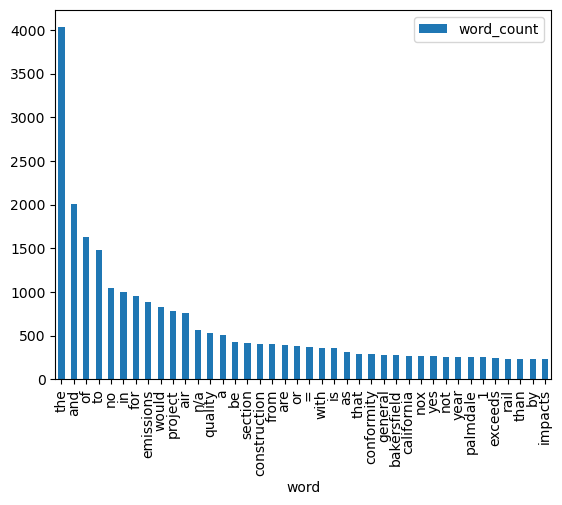

In [15]:
df.head(40).plot(kind='bar')  # you can also do hbar（縦軸と横軸の向きを変えられる）

There are also Python libraries like `wordcloud` that you can experiment with to generate word clouds and similar plots.

A major downside of word clouds are that the images are subtly biased. For example, longer words take up more space. However, they can be a nice visual to motivate an analysis.
##### word cloudという方法もあるが、これは、文字数の大きい単語の方が大きな領域を占拠するのでバイアスがかかってしまう。なので、データに忠実という意味ではbar chartの方がいい

Looking at the plot above, it's dominated by the "small" words like "the," "and," and "of." Perhaps it's distracting to include them in the analysis. We'll explore this question in the next lecture.

<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
  <li>Word counts (bags of words) are normally a helpful first step in analyzing a text.</li>
</ul>
</div>